In [14]:
!pip install opencv-python pillow -Uqq

## opencv
**OpenCV**는 "Open Source Computer Vision Library"의 약자로, **실시간 이미지 및 영상 처리**를 위한 오픈소스 라이브러리이다. 인텔에서 개발을 시작했으며, 현재는 다양한 운영체제(Windows, Linux, macOS, Android 등)와 프로그래밍 언어(Python, C++, Java 등)를 지원한다.

**Python에서 OpenCV**는 주로 `cv2` 패키지를 통해 사용하며, 이미지와 영상의 읽기, 쓰기, 변환, 필터링, 객체 인식 등 다양한 컴퓨터 비전 기능을 쉽게 구현할 수 있다.

- **이미지/영상 처리**: 이미지 읽기, 쓰기, 변환, 필터 적용, 색상 변환 등 기본적인 영상 처리 기능을 제공한다.
- **컴퓨터 비전 알고리즘**: 얼굴 인식, 객체 추적, 패턴 분석 등 고급 컴퓨터 비전 기술을 구현할 수 있다.
- **머신러닝 지원**: OpenCV에는 머신러닝 관련 함수도 내장되어 있어, 이미지 분류, 객체 검출 등에 활용할 수 있다.
- **빠른 처리 속도**: 실시간 처리를 위해 최적화되어 있으며, C++ 기반으로 개발되어 빠른 연산이 가능하다.
- **활용 분야**:
  - 얼굴 인식, 객체 추적, 자율주행, 공장 자동화, 의료 영상 분석 등 **다양한 실생활 문제 해결**에 활용된다.

In [15]:
!gdown 1zFdDejlTNGPSL5BVngJWTevOY2jipGrG

Downloading...
From: https://drive.google.com/uc?id=1zFdDejlTNGPSL5BVngJWTevOY2jipGrG
To: /content/image.jpg
100% 98.3k/98.3k [00:00<00:00, 82.0MB/s]


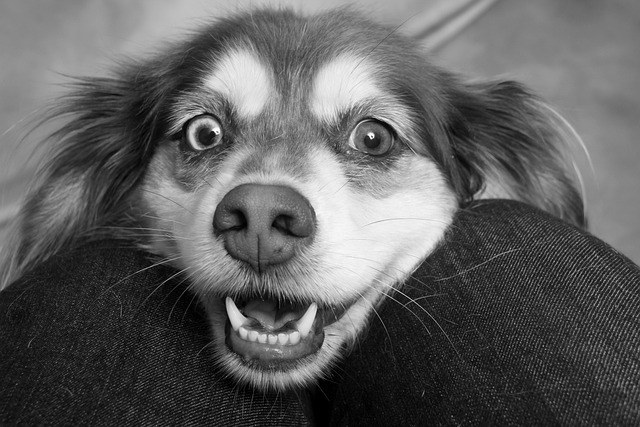

In [16]:
import cv2
from google.colab.patches import cv2_imshow

img = cv2.imread('image.jpg', cv2.IMREAD_GRAYSCALE)
cv2_imshow(img)

In [17]:
# 로컬실행
# img = cv2.imread('image.jpg')
# cv2.imshow('img', img)
# cv2.waitkey(0) # 키보드입력 무한대기
# cv2.destroyAllWindows()

In [18]:
import numpy as np
import cv2

black = np.zeros((300, 300, 3), dtype=np.uint8)
cv2.imwrite('black.png', black)

white = np.ones((300, 300, 3), dtype=np.uint8)
white[:, :, :] = 255
cv2.imwrite('white.png', white)

red = np.zeros((300, 300, 3), dtype=np.uint8)
red[:, :, 2] = 255
cv2.imwrite('red.png', red)

green = np.zeros((300, 300, 3), dtype=np.uint8)
red[:, :, 1] = 255
cv2.imwrite('green.png', green)

blue = np.zeros((300, 300, 3), dtype=np.uint8)
red[:, :, 0] = 255
cv2.imwrite('blue.png', blue)

True

### 동영상 재생
- cap.read(): colab 재생시 콘솔에 프레임 연속출력
- HTML태그 출력: 동영상 html태그를 통한 출력

In [19]:
from google.colab import drive
drive.mount('/content/drive')

BASE_PATH = '/content/drive/MyDrive/SKN Family AI/05_multimodal_rag'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
# import cv2
# import os


# video_path = os.path.join(BASE_PATH, 'videos', 'skiing.mp4')
# cap = cv2.VideoCapture(video_path)

# while cap.isOpened():
#     ret, frame = cap.read()
#     if not ret: break

#     cv2_imshow(frame)

# cap.release()

In [21]:
from IPython.display import HTML
from base64 import b64encode

video_path = os.path.join(BASE_PATH, 'videos', 'skiing.mp4')
mp4 = open(video_path, 'rb').read()
b64_str = b64encode(mp4).decode()
data_url = f'data:video/mp4;base64,{b64_str}'

HTML(f'''
<video width='200' controls>
    <source src='{data_url}' type='video/mp4'/>
</video>
''')

Output hidden; open in https://colab.research.google.com to view.

<class 'numpy.ndarray'>
img.size = (1280, 720)
img.width = 1280
img.height = 720
썸네일 변환 후 크기: (480, 270)


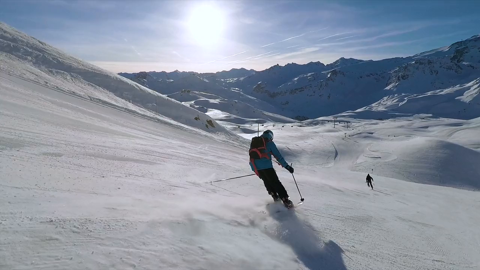

In [22]:
from PIL import Image

cap = cv2.VideoCapture(video_path)
ret, frame = cap.read()
cap.release()
print(type(frame))

frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
img = Image.fromarray(frame)

print(f'{img.size = }')
print(f'{img.width = }')
print(f'{img.height = }')

img.thumbnail((480, 270))
print(f'썸네일 변환 후 크기: {img.size}')
img

Video 파일명: alpinist.mp4
Total Frame: 677.0
FPS: 50.00
Video Length: 13.54s


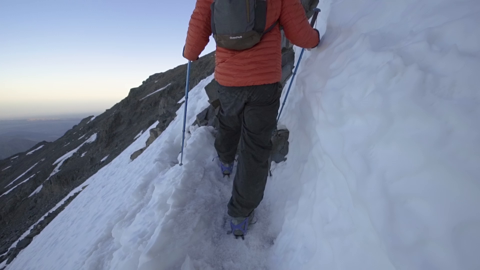



Video 파일명: baseball.mp4
Total Frame: 732.0
FPS: 50.00
Video Length: 14.64s


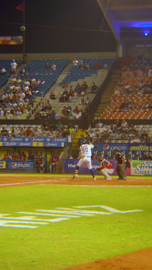



Video 파일명: basketball.mp4
Total Frame: 404.0
FPS: 25.00
Video Length: 16.16s


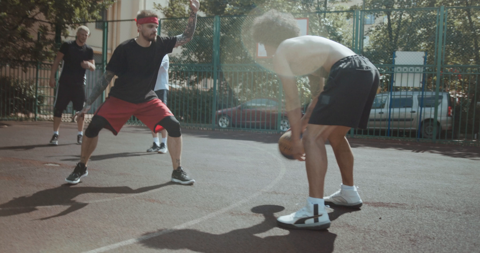



Video 파일명: skiing.mp4
Total Frame: 353.0
FPS: 25.00
Video Length: 14.12s


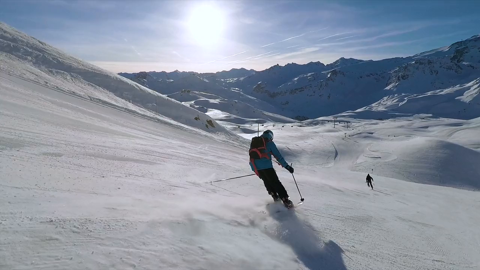



Video 파일명: soccer.mp4
Total Frame: 352.0
FPS: 25.00
Video Length: 14.08s


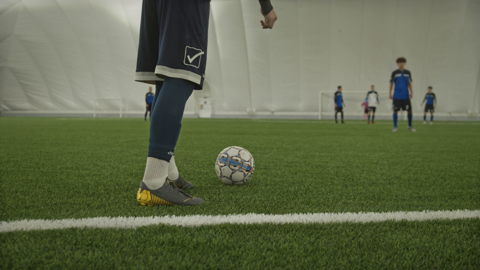

In [23]:
def show_video_summary(video_dir='videos', video_file=None, thumb_size=(240, 135)):
    assert video_file is not None, 'video_file 인수는 필수 지정'

    video_path = os.path.join(BASE_PATH, video_dir, video_file)
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f'해당 파일 열 수 없음: {video_path}')
        return

    frame_count = cap.get(cv2.CAP_PROP_FRAME_COUNT)
    fps = cap.get(cv2.CAP_PROP_FPS)
    duration = frame_count / fps if fps > 0 else 0

    ret, frame = cap.read()
    cap.release()
    if not ret:
        print(f'썸네일 추출 실패: {video_path}')
        thumbnail = None
    else:
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        thumbnail = Image.fromarray(frame_rgb)
        thumbnail.thumbnail(thumb_size)

    print(f'Video 파일명: {video_file}')
    print(f'Total Frame: {frame_count}')
    print(f'FPS: {fps:.2f}')
    print(f'Video Length: {duration:.2f}s')

    if thumbnail:
        display(thumbnail)

video_dir = 'videos'
for video_file in os.listdir(os.path.join(BASE_PATH, video_dir)):
    if video_file.endswith('.mp4'):
        show_video_summary(video_dir, video_file, thumb_size=(480, 270))
        print(end='\n\n')

In [24]:
video_dir_path = os.path.join(BASE_PATH, 'videos')
frame_dir_path = os.path.join(BASE_PATH, 'frames')
video_files = [f for f in os.listdir(video_dir_path) if f.endswith('.mp4')]

video_file_path = os.path.join(video_dir_path, 'abc.mp4')
video_file_name = os.path.splitext('abc.mp4')
video_file_name

('abc', '.mp4')

In [27]:
from tqdm.notebook import tqdm

def extract_frames_from_videos(video_dir='videos', frame_dir='frames', frame_interval=1):
    video_dir_path = os.path.join(BASE_PATH, 'videos')
    frame_dir_path = os.path.join(BASE_PATH, 'frames')
    os.makedirs(frame_dir_path, exist_ok=True)
    video_files = [f for f in os.listdir(video_dir_path) if f.endswith('.mp4')]

    for idx_file, video_file in enumerate(video_files):
        video_path = os.path.join(video_dir_path, video_file)
        video_name = os.path.splitext(video_file)[0]
        save_subdir = os.path.join(frame_dir_path, video_name)
        os.makedirs(save_subdir, exist_ok=True)

        cap = cv2.VideoCapture(video_path)
        frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        idx = 0
        saved_cnt = 0

        pbar = tqdm(total=frame_count, desc=f'{video_name}', leave=True, ncols=100)
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret: break

            if idx % frame_interval == 0:
                frame_path = os.path.join(save_subdir, f'{video_name}_frame{idx:05d}.jpg')
                cv2.imwrite(frame_path, frame)
                saved_cnt += 1
            idx += 1
            pbar.update(1)
        cap.release()
        pbar.close()

        if idx_file == len(video_files)-1:
            tqdm.write('')
        tqdm.write(f'{video_name}: 총 {frame_count} 중 {saved_cnt}개 저장')

    print('모든 동영상 프레임 추출 완료')

In [28]:
extract_frames_from_videos(frame_interval=30)

alpinist:   0%|                                                             | 0/677 [00:00<?, ?it/s]

alpinist: 총 677 중 23개 저장


baseball:   0%|                                                             | 0/732 [00:00<?, ?it/s]

baseball: 총 732 중 25개 저장


basketball:   0%|                                                           | 0/404 [00:00<?, ?it/s]

basketball: 총 404 중 14개 저장


skiing:   0%|                                                               | 0/353 [00:00<?, ?it/s]

skiing: 총 353 중 12개 저장


soccer:   0%|                                                               | 0/352 [00:00<?, ?it/s]


soccer: 총 352 중 12개 저장
모든 동영상 프레임 추출 완료
